# --- MySQL Connection Setup ---
To run our experiments, please update the MySQL connection settings in the following function to match your local database environment (host/port/user/password/database). After replacing these values, you should be able to connect to your MySQL server and execute all experiment scripts normally.


In [28]:

import json
import pathlib
import getpass
import mysql.connector
from mysql.connector import Error
import time
from itertools import chain, combinations, groupby
from prettytable import PrettyTable
import os
import csv
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


from scipy.optimize import curve_fit




def get_mysql_connection():
    return mysql.connector.connect(
        host="localhost",
        port=3306,
        user="root",             # ------- modify to your own user
        password="yzh_20010315", # ------- modify to your own password
        database="hockey",
    )


# test
try:
    conn = get_mysql_connection()
    if conn.is_connected():
        print("✔ MySQL connected successfully!")
except Error as e:
    print("Error:", e)
finally:
    if "conn" in locals() and conn.is_connected():
        conn.close()

✔ MySQL connected successfully!


# --- 10 tables ---

In [29]:
l1 = {
    'abbrev': ['Type', 'Code', 'Fullname'],
    'awardscoaches': ['coachID', 'award', 'year', 'lgID'],
    'awardsmisc': ['name', 'ID', 'award', 'year', 'lgID'],
    'awardsplayers': ['playerID', 'award', 'year', 'lgID', 'pos'],
    'coaches': ['coachID', 'year', 'tmID', 'lgID', 'stint'],
    'combinedshutouts': ['year', 'month', 'date', 'tmID', 'oppID', 'R/P', 'IDgoalie1', 'IDgoalie2'],
    'goalies': ['playerID', 'year', 'stint', 'tmID', 'lgID', 'GP'],
    'goaliessc': ['playerID', 'year', 'tmID', 'lgID', 'GP'],
    'goaliesshootout': ['playerID', 'year', 'stint', 'tmID'],
    'hof': ['year', 'hofID', 'name', 'category'],
    'master': ['playerID', 'coachID', 'hofID', 'legendsID', 'ihdbID', 'hrefID', 'lastName', 'nameGiven', 'birthYear', 'pos'],
    'scoring': ['playerID', 'year', 'stint', 'tmID', 'lgID', 'pos'],
    'scoringsc': ['playerID', 'year', 'tmID', 'lgID', 'pos'],
    'scoringshootout': ['playerID', 'year', 'stint', 'tmID'],
    'scoringsup': ['playerID', 'year'],
    'seriespost': ['year', 'round', 'series', 'tmIDWinner', 'lgIDWinner', 'tmIDLoser', 'lgIDLoser'],
    'teams': ['year', 'lgID', 'tmID', 'franchID', 'confID', 'divID', 'rank', 'name'],
    'teamshalf': ['year', 'lgID', 'tmID', 'half', 'rank'],
    'teamsplits': ['year', 'lgID', 'tmID'],
    'teamspost': ['year', 'lgID', 'tmID'],
    'teamssc': ['year', 'lgID', 'tmID'],
    'teamvsteam': ['year', 'lgID', 'tmID', 'oppID']
}


# --- Calculate Basic Parameters ---
### Calculate max/min uniqueness ratio, running time and completeness ratio

In [30]:
def get_column_names(cursor, table_name):
    cursor.execute(f"DESCRIBE `{table_name}`")
    return [column[0] for column in cursor.fetchall()]


def pmax_uniqueness_ratio_sql(cursor, table_name, columns):
    """Calculates the Maximum Uniqueness Ratio for a given column permutation"""
    if not columns:
        return 0, 0
    columns_list = ', '.join([f"`{col}`" for col in columns])
    query = f"""
        SELECT
            ((null_rows + unique_rows) / total_rows) AS uniqueness_ratio
        FROM (
            SELECT
                (SELECT COUNT(*) FROM `{table_name}` WHERE {' OR '.join([f"`{col}` IS NULL" for col in columns])}) AS null_rows,
                (
                    SELECT COUNT(*)
                    FROM (
                        SELECT {columns_list}
                        FROM `{table_name}`
                        WHERE {' AND '.join([f"`{col}` IS NOT NULL" for col in columns])}
                        GROUP BY {columns_list}
                        HAVING COUNT(*) = 1
                    ) AS unique_data
                ) AS unique_rows,
                (SELECT COUNT(*) FROM {table_name}) AS total_rows
        ) AS results;
    """
    start_time = time.time()
    cursor.execute(query)
    result = cursor.fetchone()
    execution_time = time.time() - start_time
    ratio = result[0] if result else 0
    return float(ratio), float(execution_time)


def pmin_uniqueness_ratio(cursor, table_name, columns):
    """Calculates the Minimum Uniqueness Ratio for a given column permutation"""
    columns_list = ', '.join([f"`{col}`" for col in columns])
    null_conditions = " OR ".join([f"{col} IS NULL" for col in columns])
    not_null_conditions = " AND ".join([f"{col} IS NOT NULL" for col in columns])
    insert_condition = ", ".join([f"NOTNULL_{col}" for col in columns])
    insert_condition1 = ", ".join([f"NULL_{col}" for col in columns])
    weak_similarity_condition = " AND ".join([f"(NOTNULL_{col} = NULL_{col} OR NOTNULL_{col} IS NULL OR NULL_{col} IS NULL)" for col in columns])
    checkin_condition = " AND ".join([f"({col} = NOTNULL_{col} OR ({col} IS NULL AND NOTNULL_{col} IS NULL))"for col in columns])
    declare_NOTNULL = '\n'.join([f"DECLARE NOTNULL_{col} VARCHAR(100);" for col in columns])
    declare_NULL = '\n'.join([f"DECLARE NULL_{col} VARCHAR(100);" for col in columns])

    cursor.execute("DROP PROCEDURE IF EXISTS possible_min;")
    cursor.execute("DROP TABLE IF EXISTS not_null_table;")
    cursor.execute("DROP TABLE IF EXISTS include_null_table;")
    cursor.execute(f"CREATE TABLE not_null_table AS SELECT {columns_list} FROM {table_name} WHERE {not_null_conditions};")
    cursor.execute(f"CREATE TABLE include_null_table AS SELECT {columns_list} FROM {table_name} WHERE {null_conditions};")

    query1 = f"""
        CREATE PROCEDURE possible_min()
        BEGIN
            DECLARE total_count INT DEFAULT 0;
            DECLARE unique_count INT DEFAULT 0;
            DECLARE FLAG INT;
            DECLARE done INT DEFAULT FALSE;
            {declare_NOTNULL}
            {declare_NULL}
            DECLARE cur_null CURSOR FOR SELECT * FROM include_null_table;
            DECLARE cur_not_null CURSOR FOR SELECT * FROM not_null_table;
            DECLARE CONTINUE HANDLER FOR NOT FOUND SET done = TRUE;

            DROP TEMPORARY TABLE IF EXISTS weak_similar_table;
            CREATE TEMPORARY TABLE weak_similar_table LIKE not_null_table;

            OPEN cur_null;
                outer_loop: LOOP
                    FETCH cur_null INTO {insert_condition1};
                    IF done THEN
                        LEAVE outer_loop;
                    END IF;
                    SET FLAG = 1;
                    OPEN cur_not_null;
                        inner_loop: LOOP
                            FETCH cur_not_null INTO {insert_condition};
                            IF done THEN
                                SET done = FALSE;
                                LEAVE inner_loop;
                            END IF;
                            IF ({weak_similarity_condition}) THEN
                                IF NOT EXISTS(SELECT 1 FROM weak_similar_table WHERE ({checkin_condition})) THEN
                                    INSERT INTO weak_similar_table VALUES ({insert_condition});
                                    SET FLAG = 0;
                                    SET done = FALSE;
                                    LEAVE inner_loop;
                                END IF;
                            END IF;
                        END LOOP inner_loop;
                    CLOSE cur_not_null;
                    IF FLAG = 1 THEN
                        INSERT INTO not_null_table VALUES ({insert_condition1});
                    END IF;
                END LOOP outer_loop;
            CLOSE cur_null;
            INSERT INTO weak_similar_table ({columns_list}) SELECT {columns_list} FROM not_null_table;
        END;
    """

    final_query = f"""
        SELECT
            (SELECT COUNT(*) FROM (
                SELECT COUNT(*) AS cnt
                FROM weak_similar_table
                GROUP BY {columns_list}
                HAVING COUNT(*) = 1
            ) AS unique_counts) /
            (SELECT COUNT(*) FROM {table_name}) AS ratio;
    """
    t0 = time.time()
    cursor.execute(query1)
    cursor.execute(f"CALL possible_min();")
    cursor.execute(final_query)
    row = cursor.fetchone()          # (0.12345,)
    ratio = row[0] if row and row[0] is not None else 0.0
    t = time.time() - t0
    return float(ratio), float(t)




def completeness_ratio(cursor, table_name, columns):
    """Calculates the Completeness Ratio for a given column permutation"""
    if not columns:
        return 0

    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}`;")
    total_counts = cursor.fetchone()[0]

    query = " AND ".join([f"`{col}` IS NOT NULL" for col in columns])
    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}` WHERE {query};")
    non_null_count = cursor.fetchone()[0]

    cr = non_null_count/total_counts
    return float(cr)


# --- Basic Parameter Calculation and Analysis ---
### Key Metric Computation for All Column Combinations (Hockey Database)
For each table in the **Hockey** database, computing the maximum uniqueness ratio (UR_max) and its runtime, the minimum uniqueness ratio (UR_min) and its runtime, as well as the completeness ratio (CR), across all possible combinations of columns.

All results are automatically saved to the `ur_result/` directory, with one output file per table named `{table_name}_result.csv`.

In [31]:
from pathlib import Path

def main_ur(table_name, columns):
    connection = None
    cursor = None

    try:
        base_dir = Path.cwd()
        output_dir = base_dir / "ur_result"
        output_dir.mkdir(parents=True, exist_ok=True)
        output_csv_path = output_dir / f"{table_name}_result.csv"

        connection = get_mysql_connection()
        cursor = connection.cursor()
        all_combinations = []
        for length in range(1, 6):
            all_combinations.extend(combinations(columns, length))

        detailed_output = []
        for perm in all_combinations:
            max_ratio, max_time = pmax_uniqueness_ratio_sql(cursor, table_name, perm)
            if table_name == "aa":
                min_ratio, min_time = pmin_uniqueness_ratio(cursor, table_name, perm)
            else:
                min_ratio, min_time = 0.0, 0.0
            cr = completeness_ratio(cursor, table_name, perm)
            detailed_output.append((perm, max_ratio, max_time, min_ratio, min_time, cr))

        table = PrettyTable()
        table.field_names = ["Key", "max_ratio", "max_time", "min_ratio", "min_time", "CR"]
        for perm, max_ratio, max_time, min_ratio, min_time, cr in detailed_output:
            table.add_row([
                ", ".join(perm),
                f"{max_ratio:.4f}",
                f"{max_time:.4f}",
                f"{min_ratio:.4f}",
                f"{min_time:.4f}",
                f"{cr:.4f}",
            ])
        print(table)

        headers = ["table_name", "key", "max", "max_time", "min", "min_time", "CR"]
        with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(headers)
            for perm, max_ratio, max_time, min_ratio, min_time, cr in detailed_output:
                writer.writerow([
                    table_name,
                    ", ".join(perm),
                    max_ratio,
                    max_time,
                    min_ratio,
                    min_time,
                    cr,
                ])
        print(f"\n[OK] CSV saved to: {output_csv_path}")

    except Error as e:
        print("Error:", e)

    finally:
        if cursor is not None:
            cursor.close()
        if connection is not None and connection.is_connected():
            connection.close()


for key, values in l1.items():
    print(f"Table: {key}\nColumns: {values}")
    main_ur(key, values)

Table: abbrev
Columns: ['Type', 'Code', 'Fullname']
+----------------------+-----------+----------+-----------+----------+--------+
|         Key          | max_ratio | max_time | min_ratio | min_time |   CR   |
+----------------------+-----------+----------+-----------+----------+--------+
|         Type         |   0.0000  |  0.0013  |   0.0000  |  0.0000  | 1.0000 |
|         Code         |   0.6552  |  0.0010  |   0.0000  |  0.0000  | 1.0000 |
|       Fullname       |   1.0000  |  0.0010  |   0.0000  |  0.0000  | 1.0000 |
|      Type, Code      |   1.0000  |  0.0007  |   0.0000  |  0.0000  | 1.0000 |
|    Type, Fullname    |   1.0000  |  0.0005  |   0.0000  |  0.0000  | 1.0000 |
|    Code, Fullname    |   1.0000  |  0.0005  |   0.0000  |  0.0000  | 1.0000 |
| Type, Code, Fullname |   1.0000  |  0.0006  |   0.0000  |  0.0000  | 1.0000 |
+----------------------+-----------+----------+-----------+----------+--------+

[OK] CSV saved to: /Users/zihuiyang/PycharmProjects/Identify_key/ex

### Maximum uniqueness ratio distribution graph

Reading from which folder:  /Users/zihuiyang/PycharmProjects/Identify_key/experiment/ur_result

[INFO] Plotting table: abbrev  (file=abbrev_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/abbrev_boxplot.png


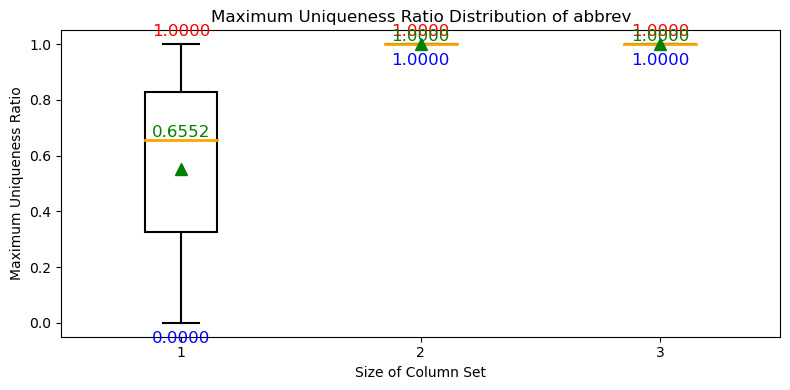


[INFO] Plotting table: awardscoaches  (file=awardscoaches_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/awardscoaches_boxplot.png


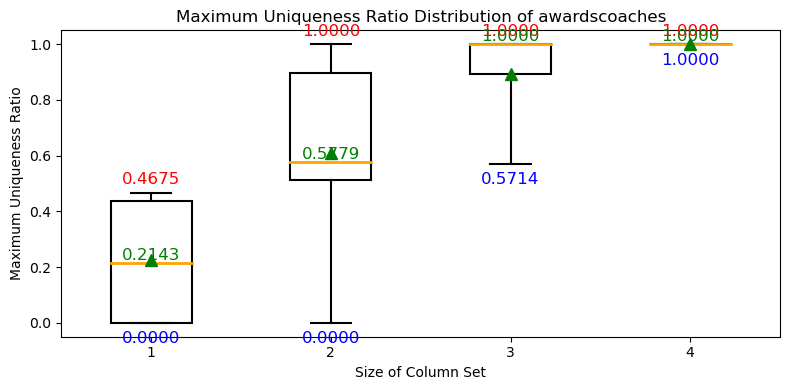


[INFO] Plotting table: awardsmisc  (file=awardsmisc_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/awardsmisc_boxplot.png


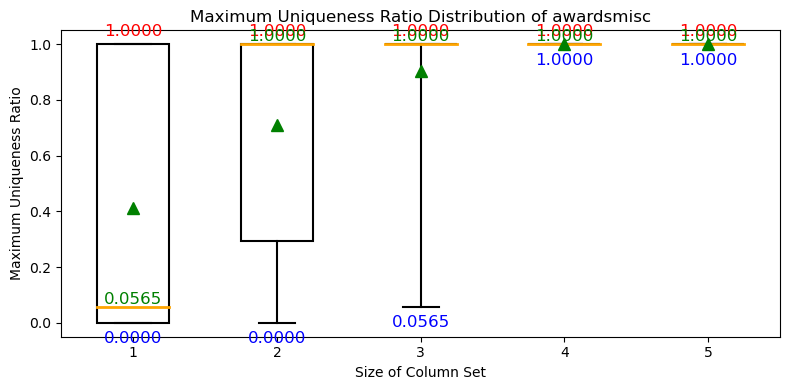


[INFO] Plotting table: awardsplayers  (file=awardsplayers_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/awardsplayers_boxplot.png


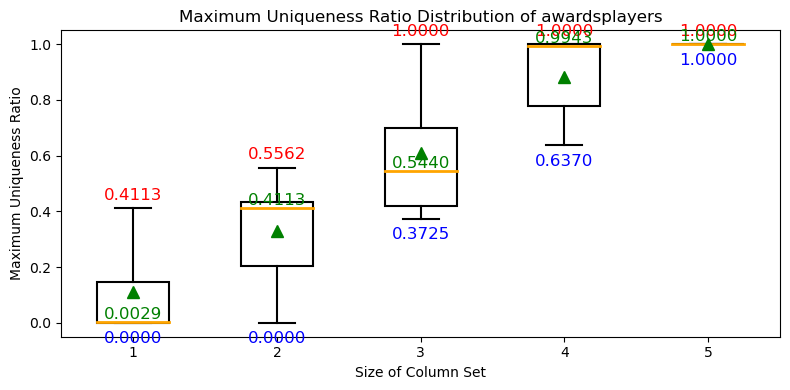


[INFO] Plotting table: coaches  (file=coaches_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/coaches_boxplot.png


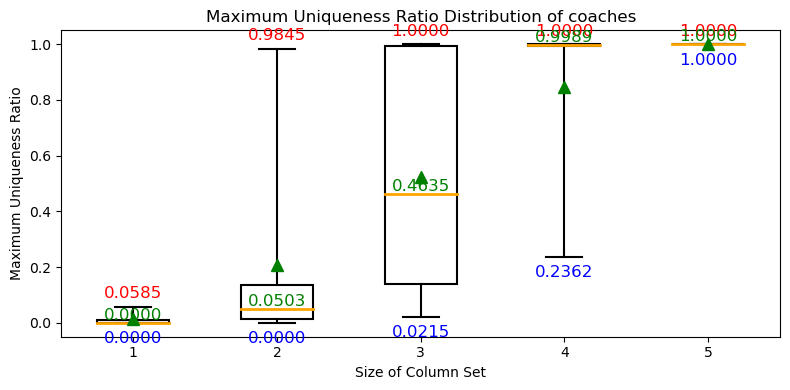


[INFO] Plotting table: combinedshutouts  (file=combinedshutouts_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/combinedshutouts_boxplot.png


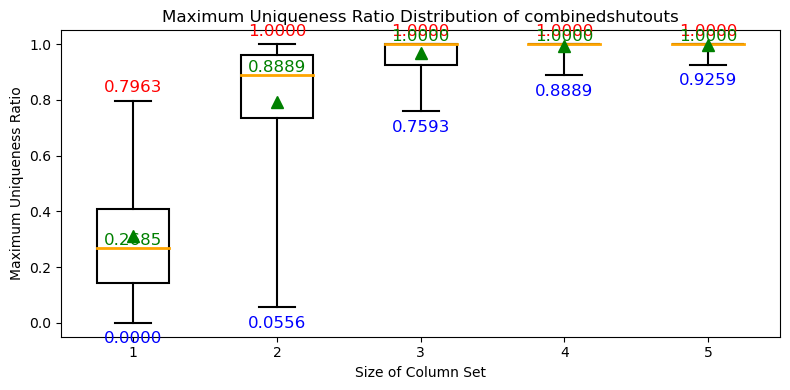


[INFO] Plotting table: goalies  (file=goalies_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/goalies_boxplot.png


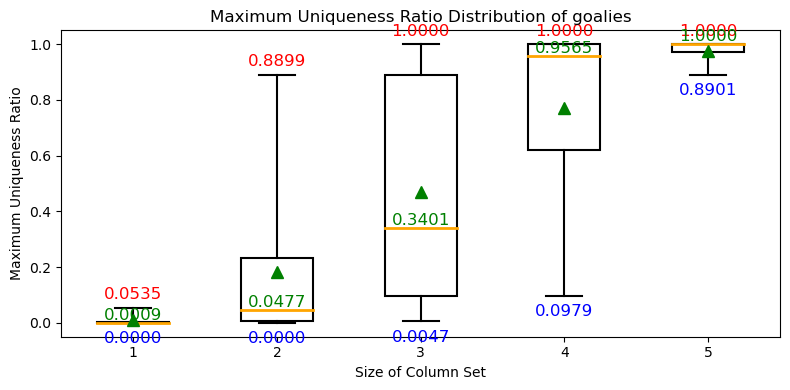


[INFO] Plotting table: goaliessc  (file=goaliessc_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/goaliessc_boxplot.png


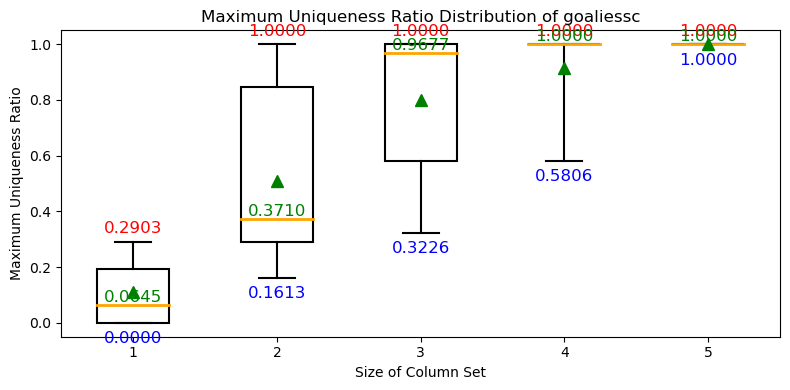


[INFO] Plotting table: goaliesshootout  (file=goaliesshootout_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/goaliesshootout_boxplot.png


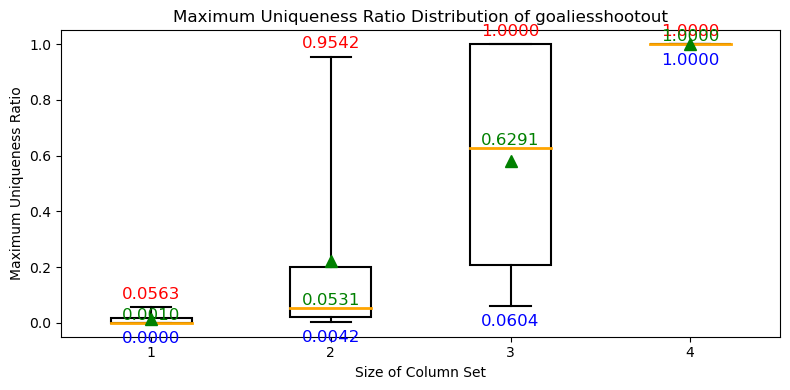


[INFO] Plotting table: hof  (file=hof_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/hof_boxplot.png


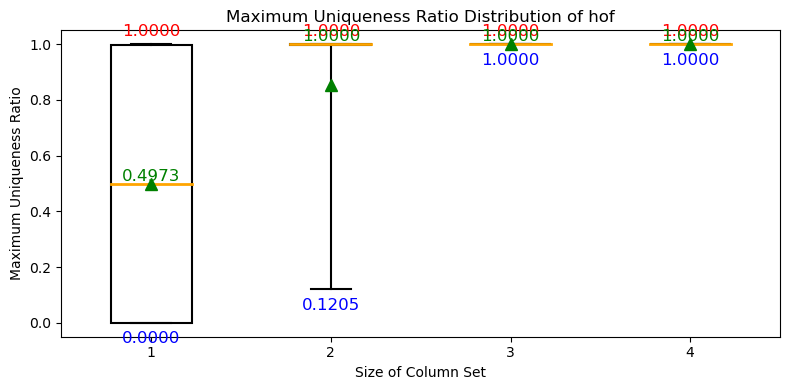


[INFO] Plotting table: master  (file=master_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/master_boxplot.png


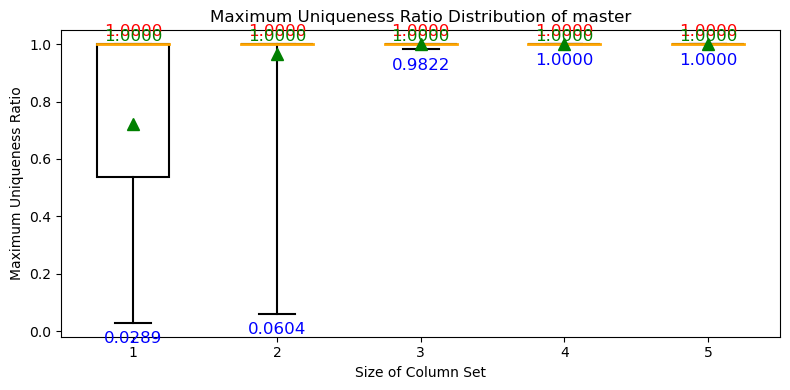


[INFO] Plotting table: scoring  (file=scoring_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/scoring_boxplot.png


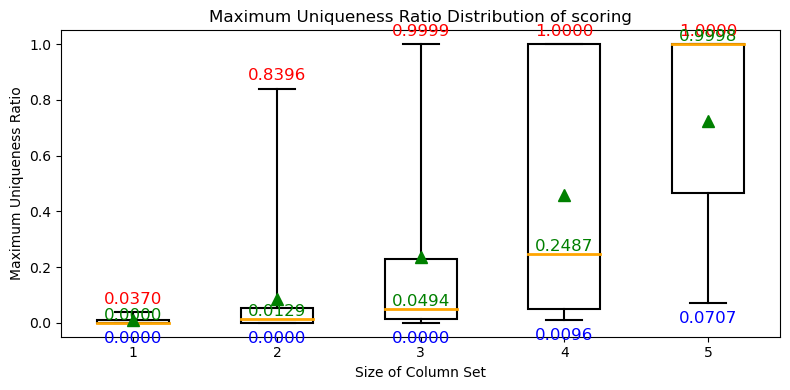


[INFO] Plotting table: scoringsc  (file=scoringsc_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/scoringsc_boxplot.png


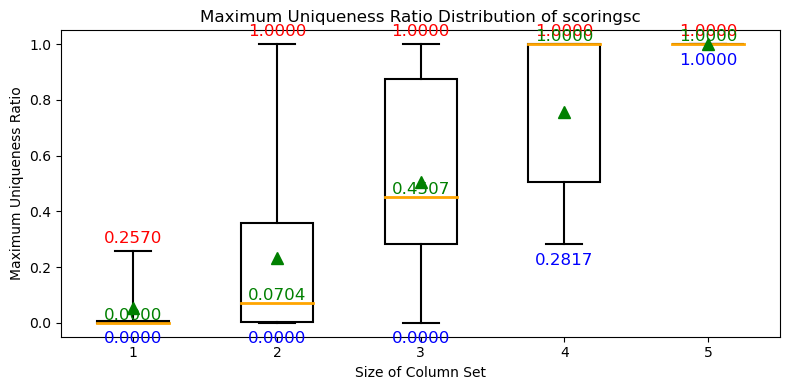


[INFO] Plotting table: scoringshootout  (file=scoringshootout_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/scoringshootout_boxplot.png


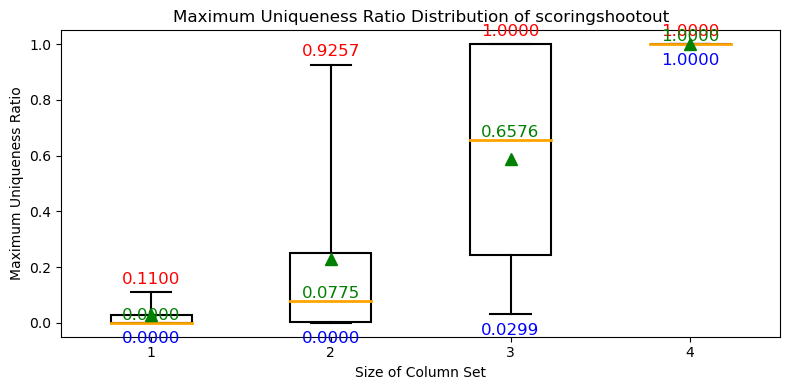


[INFO] Plotting table: scoringsup  (file=scoringsup_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/scoringsup_boxplot.png


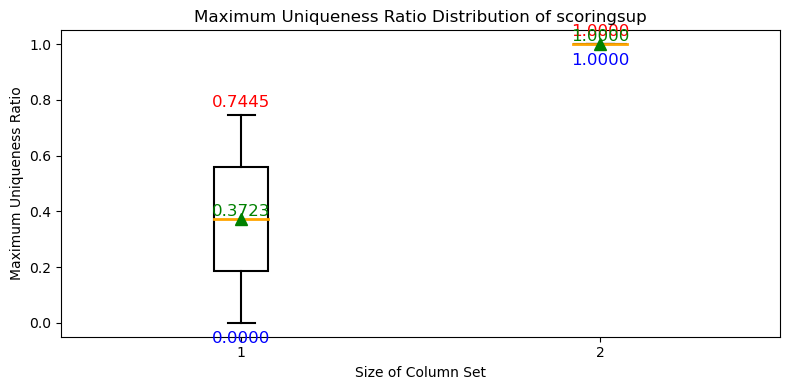


[INFO] Plotting table: seriespost  (file=seriespost_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/seriespost_boxplot.png


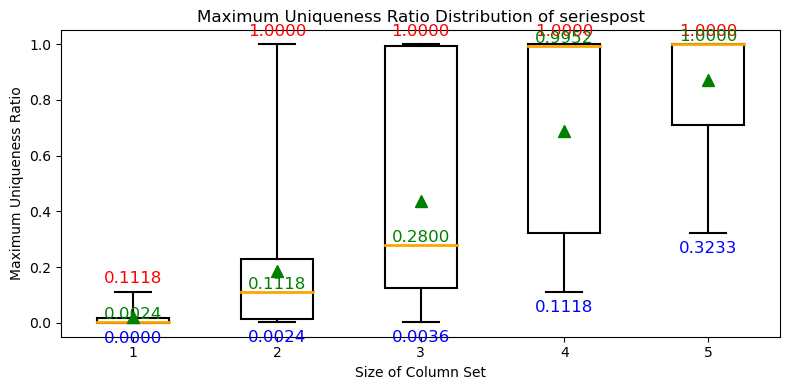


[INFO] Plotting table: teams  (file=teams_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teams_boxplot.png


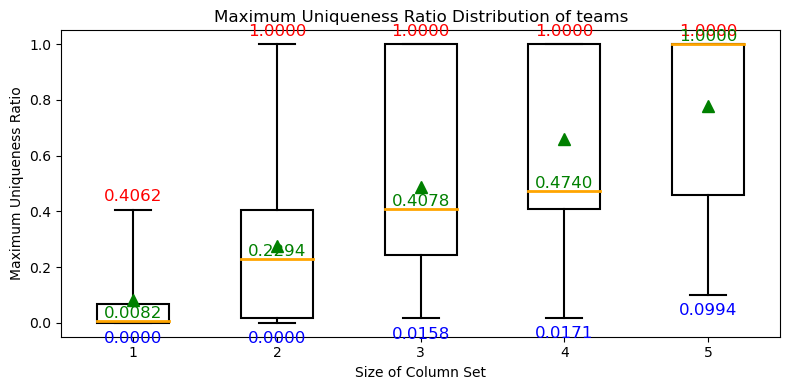


[INFO] Plotting table: teamshalf  (file=teamshalf_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teamshalf_boxplot.png


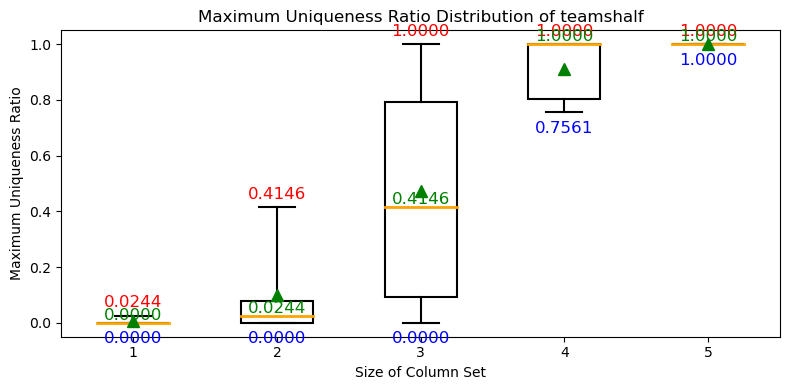


[INFO] Plotting table: teamsplits  (file=teamsplits_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teamsplits_boxplot.png


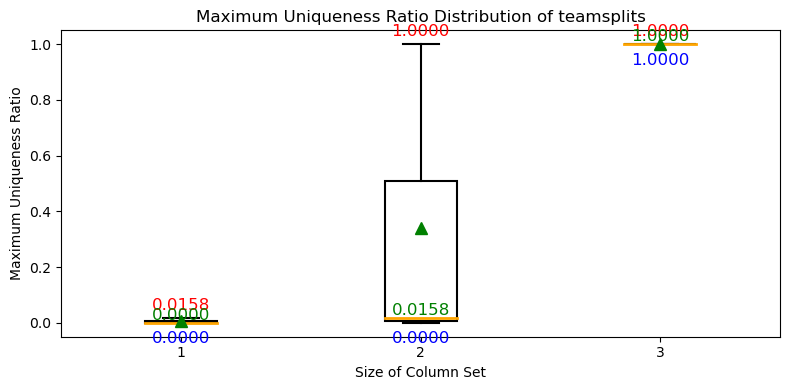


[INFO] Plotting table: teamspost  (file=teamspost_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teamspost_boxplot.png


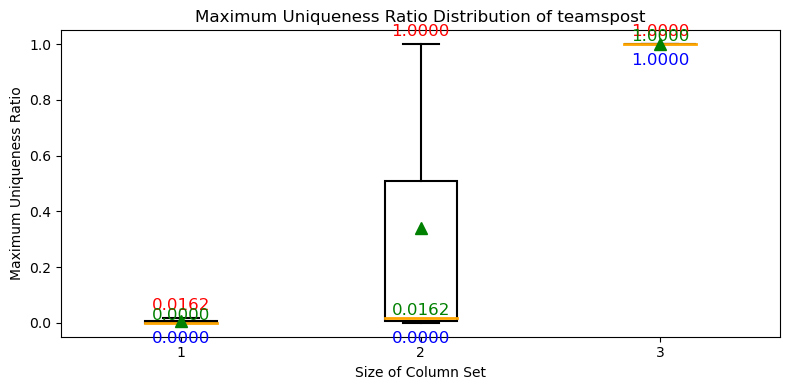


[INFO] Plotting table: teamssc  (file=teamssc_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teamssc_boxplot.png


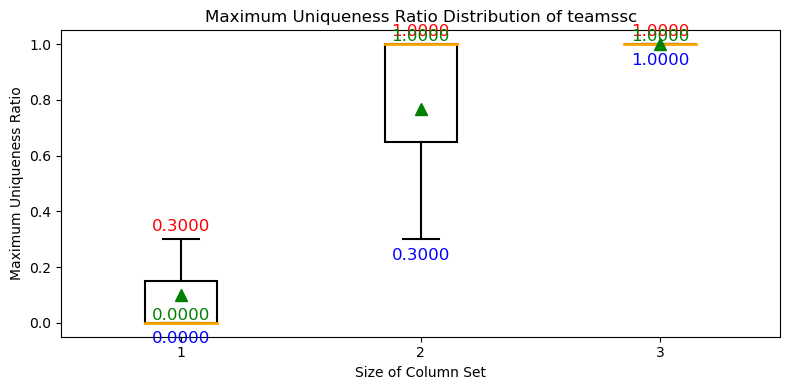


[INFO] Plotting table: teamvsteam  (file=teamvsteam_result.csv)
✅ Saved: /Users/zihuiyang/PycharmProjects/Identify_key/experiment/boxplot_result/teamvsteam_boxplot.png


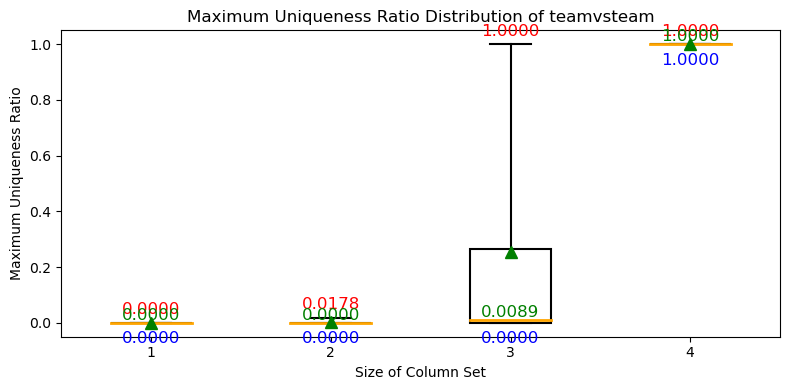

In [32]:
import os
import csv
import matplotlib.pyplot as plt
from pathlib import Path


def read_result_file(csv_path: str):
    """Read a result CSV file and groups all maximum uniqueness ratio values by key length"""
    max_by_length = {}
    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            key_str = row.get("key")
            max_str = row.get("max")

            if key_str is None or max_str is None:
                continue

            key_str = key_str.strip()
            if not key_str:
                continue

            try:
                key_len = len([x.strip() for x in key_str.split(",") if x.strip()])
                max_val = float(max_str)
            except Exception:
                continue

            if key_len not in max_by_length:
                max_by_length[key_len] = []
            max_by_length[key_len].append(max_val)

    return max_by_length


def plot_tables(table_name: str, max_by_length: dict, save_dir: Path):
    """Plot boxplot for one table and save it (styled like your example)."""
    if not max_by_length:
        print(f"[SKIP] No data for table: {table_name}")
        return

    lengths = sorted(max_by_length.keys())
    ratio_lists = [max_by_length[l] for l in lengths]

    # -------------------------
    # White background + black axes
    # -------------------------
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
    })

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # -------------------------
    # Boxplot (show mean)
    # -------------------------
    box = ax.boxplot(
        ratio_lists,
        labels=[str(length) for length in lengths],
        whis=[0, 100],
        showfliers=True,
        showmeans=True,
        patch_artist=True,
        meanprops=dict(marker="^", markerfacecolor="green", markeredgecolor="green", markersize=8),
        medianprops=dict(color="orange", linewidth=2),
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker="o", markerfacecolor="black", markeredgecolor="black", markersize=3, alpha=0.7),
    )

    ax.set_xlabel("Size of Column Set")
    ax.set_ylabel("Maximum Uniqueness Ratio")
    ax.set_title(f"Maximum Uniqueness Ratio Distribution of {table_name}")

    # -------------------------
    # Annotate min/max/median/mean
    # -------------------------
    for i, vals in enumerate(ratio_lists, start=1):
        if not vals:
            continue

        vmin = min(vals)
        vmax = max(vals)

        # median
        vmed = float(np.median(vals))

        # mean
        vmean = float(np.mean(vals))

        # --- max (red) ---
        ax.text(i, vmax + 0.02, f"{vmax:.4f}", color="red", fontsize=12, ha="center", va="bottom")

        # --- min (blue) ---
        ax.text(i, vmin - 0.03, f"{vmin:.4f}", color="blue", fontsize=12, ha="center", va="top")

        # --- median (orange text) ---
        ax.text(i, vmed, f"{vmed:.4f}", color="green", fontsize=12, ha="center", va="bottom")

        # --- mean (green text) ---
        # ax.text(i, vmean, f"{vmean:.4f}", color="orange", fontsize=12, ha="center", va="bottom")

    ax.grid(False)
    plt.tight_layout()

    # -------------------------
    # Save figure
    # -------------------------
    save_path = save_dir / f"{table_name}_boxplot.png"
    fig.savefig(save_path, dpi=300, facecolor="white")
    print(f"✅ Saved: {save_path.resolve()}")

    plt.show()
    plt.close(fig)



""" plot all tables in hockey """

base_dir = Path.cwd()
folder = base_dir / "ur_result"
print("Reading from which folder: ", folder)

# output folder: ./boxplot_result/
save_dir = base_dir / "boxplot_result"
save_dir.mkdir(parents=True, exist_ok=True)

csv_files = [p for p in folder.iterdir() if p.name.endswith(".csv")]
csv_files = sorted(csv_files, key=lambda x: x.name)

for csv_path in csv_files:
    table_name = csv_path.name.replace("_result.csv", "")
    print(f"\n[INFO] Plotting table: {table_name}  (file={csv_path.name})")
    max_by_length = read_result_file(str(csv_path))
    plot_tables(table_name, max_by_length, save_dir)


# --- Filtering Keys with Thresholds ---
Top-k keys table and near-key.

All Near-Keys across all tables are saved to the current working directory as `near_key_all.csv`


In [33]:
def get_subkeys(key_tuple):
    """Helper: get all subkeys (non-empty subsets)"""
    return set(chain.from_iterable(combinations(key_tuple, r) for r in range(1, len(key_tuple) + 1)))


def top_k_keys(table_name, folder_name="ur_result", threshold=0.95, top_k=5):
    """Top-k keys for one table + collect near-keys"""

    csv_path = os.path.join(folder_name, f"{table_name}_result.csv")
    print(f"Reading from which file: {csv_path}")

    detailed_output = {}

    # read csv
    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            perm = tuple(x.strip() for x in row["key"].split(",") if x.strip())
            ur = float(row["max"])
            cr = float(row["CR"])
            exec_time = float(row["max_time"])

            level = len(perm)
            if level not in detailed_output:
                detailed_output[level] = []
            detailed_output[level].append((perm, ur, cr, exec_time))

    excluded_elements = set()
    nk = []


    # top-k per level
    for level in sorted(detailed_output.keys()):
        entries = sorted(detailed_output[level], key=lambda x: x[1], reverse=True)
        top_k_ratios = sorted(set([e[1] for e in entries]), reverse=True)[:top_k]

        filtered_entries = []
        for perm, ur, cr, exec_time in entries:
            if ur not in top_k_ratios:
                continue
            if get_subkeys(perm).intersection(excluded_elements):
                continue
            filtered_entries.append((perm, ur, cr, exec_time))

        for perm, ur, cr, exec_time in filtered_entries:
            if ur == 1.0:
                excluded_elements.add(perm)
            if ur > threshold:
                nk.append([perm, ur, cr])

        # print Top-k for this level
        if filtered_entries:
            print(f"Column Count: {level}")
            table = PrettyTable()
            table.field_names = [f"Top-{top_k} Keys", "UR(max)", "CR", "Time(max_time)"]

            for perm, ur, cr, exec_time in filtered_entries:
                table.add_row([
                    ", ".join(perm),
                    f"{ur:.4f}",
                    f"{cr:.4f}",
                    f"{exec_time:.4f}",
                ])

            print(table)
            print()

    # ---- save near key to folder
    out_path_near = "near_key_all.csv"
    print("Writing to file:", out_path_near)

    with open(out_path_near, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["table_name", "key", "UR(max)", "CR"])

        for table_name, values in nk_dic.items():
            for combo, ur, cr in values:
                writer.writerow([
                    table_name,
                    ", ".join(combo),
                    float(ur),
                    float(cr),
                ])

    print(f"[OK] near-keys saved to: {out_path_near}")


    # print Near-Keys
    print(f"Near-Keys (UR > {threshold}):")
    table2 = PrettyTable()
    table2.field_names = ["Keys", "UR(max)", "CR"]

    for perm, ur, cr in nk:
        table2.add_row([", ".join(perm), f"{ur:.4f}", f"{cr:.4f}"])
    print(table2)

    return nk


# ----------------------------
# Run all tables in l1
# ----------------------------
nk_dic = {}

TOP_K = 5   # ✅ 这里随便改，比如 5 / 10 / 20
THRESHOLD = 0.95
for table_name in l1.keys():
    print("------------------------------------------------------------")
    print(f"Table: {table_name}")

    nk_dic[table_name] = top_k_keys(
        table_name,
        folder_name="ur_result",
        threshold=THRESHOLD,
        top_k=TOP_K
    )

print("\nDone! nk_dic is ready.")


------------------------------------------------------------
Table: abbrev
Reading from which file: ur_result/abbrev_result.csv
Column Count: 1
+------------+---------+--------+----------------+
| Top-5 Keys | UR(max) |   CR   | Time(max_time) |
+------------+---------+--------+----------------+
|  Fullname  |  1.0000 | 1.0000 |     0.0010     |
|    Code    |  0.6552 | 1.0000 |     0.0010     |
|    Type    |  0.0000 | 1.0000 |     0.0013     |
+------------+---------+--------+----------------+

Column Count: 2
+------------+---------+--------+----------------+
| Top-5 Keys | UR(max) |   CR   | Time(max_time) |
+------------+---------+--------+----------------+
| Type, Code |  1.0000 | 1.0000 |     0.0007     |
+------------+---------+--------+----------------+

Writing to file: near_key_all.csv
[OK] near-keys saved to: near_key_all.csv
Near-Keys (UR > 0.95):
+------------+---------+--------+
|    Keys    | UR(max) |   CR   |
+------------+---------+--------+
|  Fullname  |  1.0000 | 

# --- Specialisation Analysis---

In this section, we generate subkey lattice diagrams for all **near-keys** with **UR(max) = 1.0**.
All generated specialisation graphs are saved under:

`experiment/specialisation_result/`

In addition, we compare the running time of the three strategies (**Normal**, **BFS**, and **DFS**) and produce corresponding runtime comparison plots.
These figures are saved under:

`experiment/specialisation_time_result/`


In [34]:
def load_table_result_csv(table_name, folder="ur_result"):
    """Read ur_result/{table_name}_result.csv -> data_dic"""
    csv_path = os.path.join(folder, f"{table_name}_result.csv")
    data_dic = {}

    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            perm = tuple(x.strip() for x in row["key"].split(",") if x.strip())
            pur = float(row["max"])
            cur = float(row["min"])
            cr = float(row["CR"])
            tmax = float(row["max_time"])
            tmin = float(row["min_time"])
            data_dic[perm] = {
                "PUR": pur,
                "CUR": cur,
                "CR": cr,
                "Tmax": tmax,
                "Tmin": tmin,
            }

    # add empty set node
    data_dic[("φ",)] = {"PUR": 0.0, "CUR": 0.0, "CR": 1.0, "Tmax": 0.0, "Tmin": 0.0}

    return data_dic



def is_subset(super_set, sub_set):
    """Subset helper"""
    if str(sub_set) == "φ" or sub_set == ("φ",):
        return True
    return set(sub_set).issubset(set(super_set)) and set(super_set) != set(sub_set)



def bfs_subkey(key, data_dic):
    """BFS / Normal / DFS (your logic, slight fix for φ tuple)"""
    sub_column = []
    pur_dic, cur_dic, cr_dic = {}, {}, {}
    check_list = []

    for r in range(len(key), 0, -1):
        subsets = list(itertools.combinations(key, r))
        ll = []
        for subkey in subsets:
            pur = data_dic[subkey]["PUR"]
            flag = any(is_subset(check_key, subkey) for check_key in check_list)
            if not flag:
                ll.append(subkey)
                pur_dic[subkey] = pur
                cur_dic[subkey] = data_dic[subkey]["CUR"]
                cr_dic[subkey] = data_dic[subkey]["CR"]
                if pur < 0.95:
                    check_list.append(subkey)
        sub_column.append(ll)

    return sub_column, pur_dic, cur_dic, cr_dic


def normal_subkey(key, data_dic):
    sub_column = []
    pur_dic, cur_dic, cr_dic = {}, {}, {}

    for r in range(1, len(key) + 1):
        subsets = list(itertools.combinations(key, r))
        sub_column.append(subsets)

    sub_column = sub_column[::-1]

    for sublist in sub_column:
        for subkey in sublist:
            pur_dic[subkey] = data_dic[subkey]["PUR"]
            cur_dic[subkey] = data_dic[subkey]["CUR"]
            cr_dic[subkey] = data_dic[subkey]["CR"]

    sub_column.append([("φ",)])
    pur_dic[("φ",)] = 0.0
    cur_dic[("φ",)] = 0.0
    cr_dic[("φ",)] = 1.0

    return sub_column, pur_dic, cur_dic, cr_dic


def dfs_subkey(key, data_dic):
    columns, pur_all, cur_all, cr_all = normal_subkey(key, data_dic)
    start_node = max([k for k in pur_all.keys() if k != ("φ",)], key=len)
    stack = [start_node]
    visited = set()
    result = []

    while stack:
        current_node = stack.pop()
        if current_node in visited:
            continue
        visited.add(current_node)

        pur = pur_all.get(current_node, None)
        if pur is None:
            continue

        result.append(current_node)
        if pur < 0.95:
            continue

        for i in range(len(current_node)):
            child_node = current_node[:i] + current_node[i + 1 :]
            if child_node not in visited:
                stack.append(child_node)

    result.sort(key=len, reverse=True)
    grouped_data = [list(group) for _, group in groupby(result, key=len)]
    pur_dic = {k: pur_all[k] for k in result}
    cur_dic = {k: cur_all[k] for k in result}
    cr_dic = {k: cr_all[k] for k in result}

    return grouped_data, pur_dic, cur_dic, cr_dic


def abbreviate_key(node, abbr_map, sort_by_abbr=True):
    """Abbreviation"""
    if node == ("φ",) or str(node) == "φ":
        return "φ"

    letters = [abbr_map.get(attr, attr[:1].upper()) for attr in node]
    if sort_by_abbr:
        letters = sorted(letters)
    return "".join(letters)


def draw_vertical_lattice(data,node_spacing=4,node_size=8000,font_size=14,pur_ratios=None,cur_ratios=None,cr_ratios=None,pur_times=None,cur_times=None,abbr_map=None,title=None,save_path=None,):
    """Draw lattice with time on node labels (max/min time)"""
    G = nx.DiGraph()
    unique_nodes = {}
    for level_idx, level in enumerate(data):
        for node_idx, node in enumerate(level):
            unique_nodes.setdefault(node, {})
            unique_nodes[node]["pos"] = ((node_idx - len(level) / 2) * node_spacing, -level_idx)

    for node, attrs in unique_nodes.items():
        name = abbreviate_key(node, abbr_map) if abbr_map else ", \n".join(node)
        pur = pur_ratios.get(node, 0.0) if pur_ratios else 0.0
        # cur = cur_ratios.get(node, 0.0) if cur_ratios else 0.0
        cr = cr_ratios.get(node, 0.0) if cr_ratios else 0.0
        t_pur = pur_times.get(node, None) if pur_times else None
        # t_cur = cur_times.get(node, None) if cur_times else None
        pur_time_str = f", {t_pur:.4f}s" if t_pur is not None else ""
        # cur_time_str = f", {t_cur:.4f}s" if t_cur is not None else ""
        # label = (
        #     f"{name}\n"
        #     f"max:{pur*100:.1f}%{pur_time_str}\n"
        #     f"min:{cur*100:.1f}%{cur_time_str}\n"
        #     f"CR:{cr*100:.1f}%"
        # )
        label = (
            f"{name}\n"
            f"({pur:.4f})\n"
        )
        G.add_node(node, pos=attrs["pos"], label=label)

    for level_idx in range(len(data) - 1):
        for parent in data[level_idx]:
            for child in data[level_idx + 1]:
                if is_subset(parent, child):
                    G.add_edge(parent, child)

    plt.figure(figsize=(18, 12), constrained_layout=True)
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")

    pos = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=node_size,
        node_color="skyblue",
        font_size=font_size,
        font_weight="bold",
        arrows=True,
    )

    if title:
        plt.title(title, fontsize=18)


    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.close()




def draw_vertical_lattice_pruning(data,node_spacing=4,node_size=8000,font_size=14,pur_ratios=None,cur_ratios=None,cr_ratios=None,pur_times=None,cur_times=None,abbr_map=None,prune_threshold=0.95,title=None,save_path=None,):
    """Draw purning lattice with time on node labels (max/min time)"""
    G = nx.DiGraph()

    unique_nodes = {}
    for level_idx, level in enumerate(data):
        for node_idx, node in enumerate(level):
            unique_nodes.setdefault(node, {})
            unique_nodes[node]["pos"] = ((node_idx - len(level) / 2) * node_spacing, -level_idx)

    for node, attrs in unique_nodes.items():
        name = abbreviate_key(node, abbr_map) if abbr_map else ", \n".join(node)

        pur = pur_ratios.get(node, 0.0) if pur_ratios else 0.0
        # cur = cur_ratios.get(node, 0.0) if cur_ratios else 0.0
        cr = cr_ratios.get(node, 0.0) if cr_ratios else 0.0

        # t_pur = pur_times.get(node, None) if pur_times else None
        # t_cur = cur_times.get(node, None) if cur_times else None

        # pur_time_str = f", {t_pur:.4f}s" if t_pur is not None else ""
        # cur_time_str = f", {t_cur:.4f}s" if t_cur is not None else ""

        # label = (
        #     f"{name}\n"
        #     f"max:{pur*100:.1f}%{pur_time_str}\n"
        #     f"min:{cur*100:.1f}%{cur_time_str}\n"
        #     f"CR:{cr*100:.1f}%"
        # )

        label = (
            f"{name}\n"
            f"({pur:.4f})\n"
        )

        G.add_node(node, pos=attrs["pos"], label=label)

    def connect_to_first_parent(node, current_level_idx):
        for parent_level_idx in range(current_level_idx - 1, -1, -1):
            for parent_node in data[parent_level_idx]:
                if is_subset(parent_node, node):
                    parent_pur = pur_ratios.get(parent_node, 0.0) if pur_ratios else 0.0
                    if parent_pur > prune_threshold:
                        G.add_edge(parent_node, node)
                        return

    for level_idx in range(1, len(data)):
        for node in data[level_idx]:
            connect_to_first_parent(node, level_idx)

    plt.figure(figsize=(18, 12), constrained_layout=True)

    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")

    pos = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=node_size,
        node_color="skyblue",
        font_size=font_size,
        font_weight="bold",
        arrows=True,
    )

    if title:
        plt.title(title, fontsize=18)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.close()





# ============================================================
# Main: draw specialisation graphs for all URmax==1 keys
# ============================================================

BASE_DIR = Path.cwd()
ur_result_folder  = BASE_DIR / "ur_result"

output_folder = BASE_DIR / "specialisation_result"
time_folder   = BASE_DIR / "specialisation_time_result"

output_folder.mkdir(parents=True, exist_ok=True)
time_folder.mkdir(parents=True, exist_ok=True)

ur1_keys_by_table = {}
near_key_csv_path="near_key_all.csv"
with open(near_key_csv_path, mode="r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    print("Reading: ", near_key_csv_path)
    for row in reader:
        table_name = row["table_name"].strip()
        key_tuple = tuple(x.strip() for x in row["key"].split(",") if x.strip())
        ur = float(row["UR(max)"])
        if ur == 1.0:
            ur1_keys_by_table.setdefault(table_name, []).append(key_tuple)


for table_name, key_list in ur1_keys_by_table.items():
    print("============================================================")
    print(f"[TABLE] {table_name} | URmax==1 keys: {len(key_list)}")

    data_dic = load_table_result_csv(table_name, str(ur_result_folder))

    pur_times = {k: v["Tmax"] for k, v in data_dic.items()}
    cur_times = {k: v["Tmin"] for k, v in data_dic.items()}

    abbr_map = None

    for key in key_list:
        if key not in data_dic:
            print(f"[SKIP] key not found in ur_result csv: {key}")
            continue

        print(f"\n[KEY] {key}")

        raw_key_name = "__".join(key)
        clean_key_name = "".join(
            ch if (ch.isalnum() or ch in ("_", "-", ".")) else "_"
            for ch in raw_key_name
        )

        # ============================================================
        # Normal
        # ============================================================
        sub_column, pur_dic, cur_dic, cr_dic = normal_subkey(key, data_dic)

        save_path = output_folder / f"{table_name}__{clean_key_name}__normal.png"

        draw_vertical_lattice(
            sub_column,
            node_spacing=5,
            node_size=10000,
            font_size=17,
            pur_ratios=pur_dic,
            cur_ratios=cur_dic,
            cr_ratios=cr_dic,
            pur_times=pur_times,
            cur_times=cur_times,
            abbr_map=abbr_map,
            title=f"Table={table_name} | Key={key} | Strategy=Normal",
            save_path=str(save_path),
        )
        print(f"[SAVED] {save_path}")

        # ============================================================
        # BFS pruning
        # ============================================================
        sub_column_bfs, pur_bfs, cur_bfs, cr_bfs = bfs_subkey(key, data_dic)

        save_path = output_folder / f"{table_name}__{clean_key_name}__bfs.png"

        draw_vertical_lattice_pruning(
            sub_column_bfs,
            node_spacing=5,
            node_size=10000,
            font_size=17,
            pur_ratios=pur_bfs,
            cur_ratios=cur_bfs,
            cr_ratios=cr_bfs,
            pur_times=pur_times,
            cur_times=cur_times,
            abbr_map=abbr_map,
            prune_threshold=0.95,
            title=f"Table={table_name} | Key={key} | Strategy=BFS (pruning)",
            save_path=str(save_path),
        )
        print(f"[SAVED] {save_path}")

        # ============================================================
        # DFS pruning
        # ============================================================
        sub_column_dfs, pur_dfs, cur_dfs, cr_dfs = dfs_subkey(key, data_dic)

        save_path = output_folder / f"{table_name}__{clean_key_name}__dfs.png"

        draw_vertical_lattice_pruning(
            sub_column_dfs,
            node_spacing=5,
            node_size=10000,
            font_size=17,
            pur_ratios=pur_dfs,
            cur_ratios=cur_dfs,
            cr_ratios=cr_dfs,
            pur_times=pur_times,
            cur_times=cur_times,
            abbr_map=abbr_map,
            prune_threshold=0.95,
            title=f"Table={table_name} | Key={key} | Strategy=DFS (pruning)",
            save_path=str(save_path),
        )
        print(f"[SAVED] {save_path}")

        # ============================================================
        # Time plot (Normal vs BFS vs DFS) + exponential fit + save
        # ============================================================

        def compute_time(sub_ratio_keys, data_dic, time_field="Tmax"):
            time_dic = {}

            for k in sub_ratio_keys.keys():
                if k == ("φ",):
                    continue

                key_length = len(k)
                time_dic.setdefault(key_length, [])

                t = 0.0
                for k2 in sub_ratio_keys.keys():
                    if k2 == ("φ",):
                        continue
                    if set(k2).issubset(set(k)) and set(k2) != set(k):
                        t += float(data_dic[k2][time_field])

                time_dic[key_length].append(round(t, 6))

            return {L: (sum(v) / len(v)) for L, v in time_dic.items()}

        def exp_func(x, a, b):
            return a * np.exp(b * x)

        def calculate_r_squared(y_true, y_pred):
            ss_res = np.sum((y_true - y_pred) ** 2)
            ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
            return 1 - (ss_res / ss_tot)

        avg_normal_time = compute_time(pur_dic, data_dic, time_field="Tmax")
        avg_bfs_time    = compute_time(pur_bfs, data_dic, time_field="Tmax")
        avg_dfs_time    = compute_time(pur_dfs, data_dic, time_field="Tmax")

        x1 = sorted(avg_normal_time.keys())
        x2 = sorted(avg_bfs_time.keys())
        x3 = sorted(avg_dfs_time.keys())

        y1 = [avg_normal_time[k] for k in x1]
        y2 = [avg_bfs_time[k] for k in x2]
        y3 = [avg_dfs_time[k] for k in x3]

        def try_fit(x, y):
            if len(x) < 2:
                return None, None, None, False

            x_arr = np.array(x, dtype=float)
            y_arr = np.array(y, dtype=float)


            if np.allclose(y_arr, y_arr[0]):
                return None, None, None, False

            try:
                p0 = (max(y_arr[0], 1e-6), 0.1)
                popt, _ = curve_fit(
                    exp_func,
                    x_arr,
                    y_arr,
                    p0=p0,
                    maxfev=30000,
                )

                y_fit = exp_func(x_arr, *popt)
                r2 = calculate_r_squared(y_arr, y_fit)
                return popt, y_fit, r2, True

            except Exception:
                return None, None, None, False


        popt1, _, r2_1, ok1 = try_fit(x1, y1)
        popt2, _, r2_2, ok2 = try_fit(x2, y2)
        popt3, _, r2_3, ok3 = try_fit(x3, y3)

        # =========================
        # Time plot (fixed colors + readable)
        # =========================
        plt.figure(figsize=(12, 6), constrained_layout=True)

        fig = plt.gcf()
        ax = plt.gca()

        # 强制白底 + 黑色字体（避免 Jupyter dark theme 影响）
        fig.set_facecolor("white")
        ax.set_facecolor("white")

        ax.tick_params(axis="both", colors="black", labelsize=12)
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
        for spine in ax.spines.values():
            spine.set_color("black")

        ax.grid(True, color="0.85")

        # ----------------------------
        # Normal (Blue)
        # ----------------------------
        if ok1:
            ax.plot(x1, y1, "o-", color="blue", label=f"Normal (R²={r2_1:.4f})")
            xs = np.linspace(min(x1), max(x1), 100)
            ax.plot(xs, exp_func(xs, *popt1), "--", color="blue", label="Fit Normal")
        else:
            ax.plot(x1, y1, "o-", color="blue", label="Normal")

        # ----------------------------
        # BFS (Green)
        # ----------------------------
        if ok2:
            ax.plot(x2, y2, "o-", color="green", label=f"BFS (R²={r2_2:.4f})")
            xs = np.linspace(min(x2), max(x2), 100)
            ax.plot(xs, exp_func(xs, *popt2), "--", color="green", label="Fit BFS")
        else:
            ax.plot(x2, y2, "o-", color="green", label="BFS")

        # ----------------------------
        # DFS (Red)
        # ----------------------------
        if ok3:
            ax.plot(x3, y3, "o-", color="red", label=f"DFS (R²={r2_3:.4f})")
            xs = np.linspace(min(x3), max(x3), 100)
            ax.plot(xs, exp_func(xs, *popt3), "--", color="red", label="Fit DFS")
        else:
            ax.plot(x3, y3, "o-", color="red", label="DFS")

        # 数值标注（强制黑色）
        for x, y in zip(x1, y1):
            ax.text(x, y, f"{y:.4f}", fontsize=10, color="black", ha="right", va="bottom")
        for x, y in zip(x2, y2):
            ax.text(x, y, f"{y:.4f}", fontsize=10, color="black", ha="left", va="top")
        for x, y in zip(x3, y3):
            ax.text(x, y, f"{y:.4f}", fontsize=10, color="black", ha="right", va="top")

        ax.set_xlabel("Key Length", fontsize=14)
        ax.set_ylabel("Average Running Time (seconds)", fontsize=14)
        ax.set_title(f"Running Time (Exponential Fit)\nTable={table_name} | Key={key}", fontsize=16)

        # legend 强制白底黑字
        leg = ax.legend(fontsize=10, frameon=True)
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_edgecolor("black")
        for t in leg.get_texts():
            t.set_color("black")

        time_plot_path = time_folder / f"{table_name}__{clean_key_name}__time_fit.png"
        plt.savefig(str(time_plot_path), dpi=300, bbox_inches="tight", facecolor="white")
        plt.close()

        print(f"[SAVED] {time_plot_path}")





Reading:  near_key_all.csv
[TABLE] abbrev | URmax==1 keys: 2

[KEY] ('Fullname',)
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Fullname__normal.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Fullname__bfs.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Fullname__dfs.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_time_result/abbrev__Fullname__time_fit.png

[KEY] ('Type', 'Code')
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Type__Code__normal.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Type__Code__bfs.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_result/abbrev__Type__Code__dfs.png
[SAVED] /Users/zihuiyang/PycharmProjects/Identify_key/experiment/specialisation_t

# --- Counter-example Analysis ---
This section implements **(1) Visualising Data Duplication** and **(2) Counter-example Analysis** for the selected near-keys.
All generated figures are saved to:

`/experiment/counter_example_result`


In addition, the code prints the **duplicate instances (counter-examples)** for each key, which can be used to manually inspect whether the table contains **potential dirty data** or unexpected violations of the key constraints.



[OK] loaded 103 near-keys from: near_key_all.csv

==================== Table: awardsplayers; Near-key: ('playerID', 'year', 'pos') ====================

[INFO] Only one degree found (Degree=2). Skip bar/pie plots and show duplicate instances only.

--- Table=awardsplayers | Key=(playerID, year, pos) | Degree=2 | Rows=6 ---
+---+-----------+------+-----+-------------+
| # |  playerID | year | pos | group_count |
+---+-----------+------+-----+-------------+
| 1 | barrato01 | 1983 |  G  |      2      |
| 2 | belfoed01 | 1990 |  G  |      2      |
| 3 | hextaro01 | 1986 |  G  |      2      |
| 4 | masonst01 | 2008 |  G  |      2      |
| 5 | robitlu01 | 1986 |  LW |      2      |
+---+-----------+------+-----+-------------+
[INFO] Showing only first 5 rows for Degree=2.

==================== Table: awardsplayers; Near-key: ('playerID', 'year', 'lgID', 'pos') ====================

[INFO] Only one degree found (Degree=2). Skip bar/pie plots and show duplicate instances only.

--- Table=award

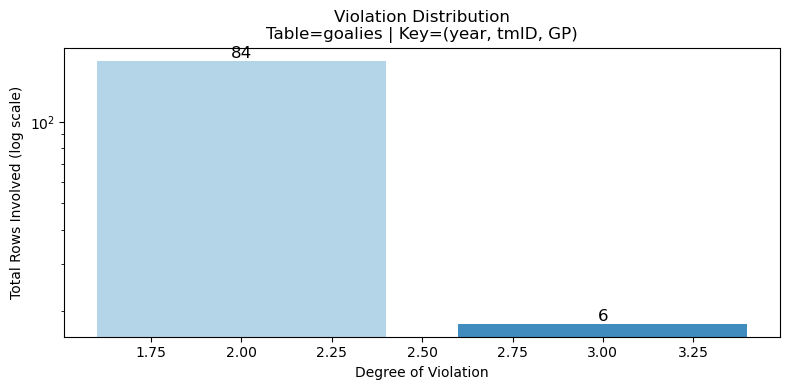

[SAVED] counter_example_result/goalies__year__tmID__GP__pie.png


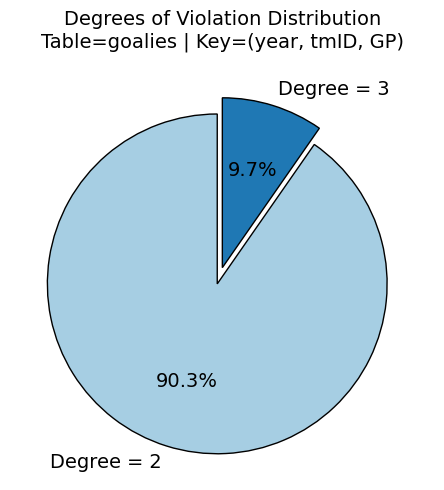


--- Table=goalies | Key=(year, tmID, GP) | Degree=3 | Rows=6 ---
+---+------+------+----+-------------+
| # | year | tmID | GP | group_count |
+---+------+------+----+-------------+
| 1 | 1943 | BOS  | 1  |      3      |
| 2 | 1931 | NYA  | 1  |      3      |
| 3 | 1968 | STL  | 1  |      3      |
| 4 | 1933 | NYA  | 1  |      3      |
| 5 | 1931 | TOR  | 1  |      3      |
+---+------+------+----+-------------+
[INFO] Showing only first 5 rows for Degree=3.

--- Table=goalies | Key=(year, tmID, GP) | Degree=2 | Rows=84 ---
+---+------+------+----+-------------+
| # | year | tmID | GP | group_count |
+---+------+------+----+-------------+
| 1 | 1984 | EDM  | 1  |      2      |
| 2 | 1972 | PHI  | 23 |      2      |
| 3 | 1991 | BOS  | 8  |      2      |
| 4 | 1990 | DET  | 3  |      2      |
| 5 | 1991 | DET  | 1  |      2      |
+---+------+------+----+-------------+
[INFO] Showing only first 5 rows for Degree=2.

==================== Table: goalies; Near-key: ('playerID', 'year', 't

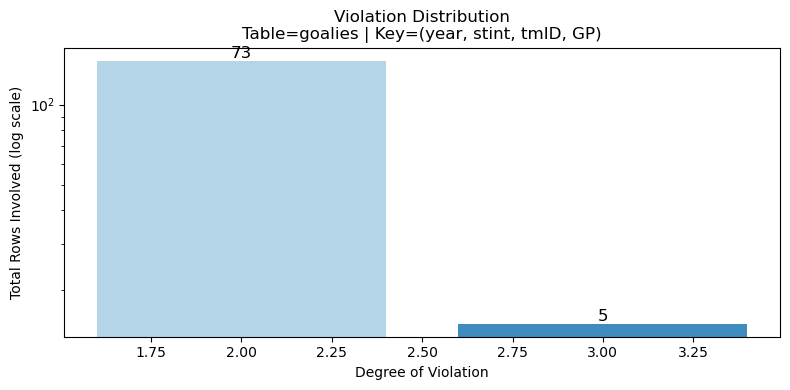

[SAVED] counter_example_result/goalies__year__stint__tmID__GP__pie.png


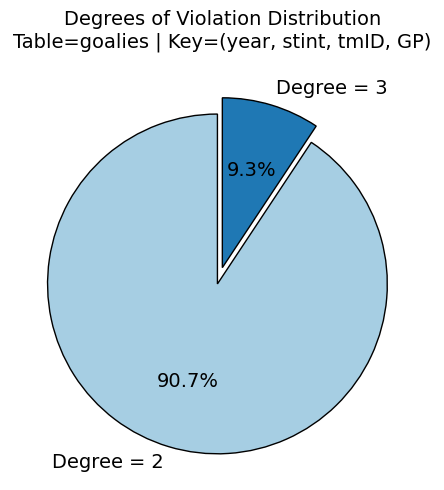


--- Table=goalies | Key=(year, stint, tmID, GP) | Degree=3 | Rows=5 ---
+---+------+-------+------+----+-------------+
| # | year | stint | tmID | GP | group_count |
+---+------+-------+------+----+-------------+
| 1 | 1943 |   1   | BOS  | 1  |      3      |
| 2 | 1931 |   1   | NYA  | 1  |      3      |
| 3 | 1968 |   1   | STL  | 1  |      3      |
| 4 | 1931 |   1   | TOR  | 1  |      3      |
| 5 | 1963 |   1   | DET  | 1  |      3      |
+---+------+-------+------+----+-------------+

--- Table=goalies | Key=(year, stint, tmID, GP) | Degree=2 | Rows=73 ---
+---+------+-------+------+----+-------------+
| # | year | stint | tmID | GP | group_count |
+---+------+-------+------+----+-------------+
| 1 | 1984 |   1   | EDM  | 1  |      2      |
| 2 | 1979 |   1   | BOS  | 1  |      2      |
| 3 | 1972 |   1   | PHI  | 23 |      2      |
| 4 | 1991 |   1   | BOS  | 8  |      2      |
| 5 | 1991 |   1   | DET  | 1  |      2      |
+---+------+-------+------+----+-------------+
[INFO] 

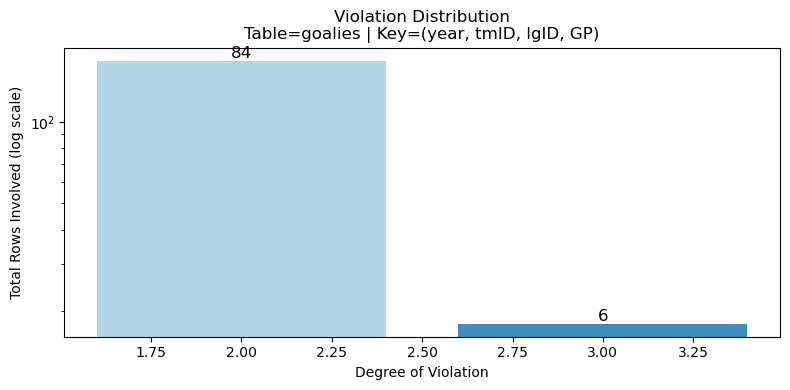

[SAVED] counter_example_result/goalies__year__tmID__lgID__GP__pie.png


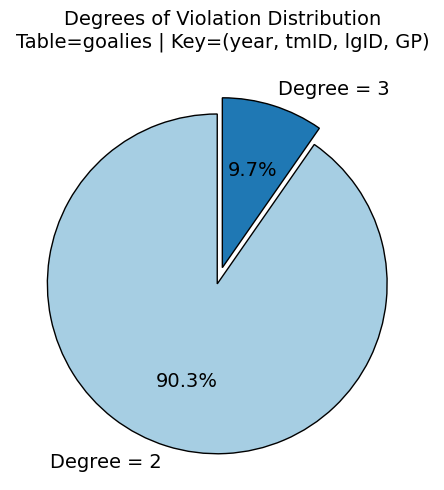


--- Table=goalies | Key=(year, tmID, lgID, GP) | Degree=3 | Rows=6 ---
+---+------+------+------+----+-------------+
| # | year | tmID | lgID | GP | group_count |
+---+------+------+------+----+-------------+
| 1 | 1943 | BOS  | NHL  | 1  |      3      |
| 2 | 1931 | NYA  | NHL  | 1  |      3      |
| 3 | 1968 | STL  | NHL  | 1  |      3      |
| 4 | 1933 | NYA  | NHL  | 1  |      3      |
| 5 | 1931 | TOR  | NHL  | 1  |      3      |
+---+------+------+------+----+-------------+
[INFO] Showing only first 5 rows for Degree=3.

--- Table=goalies | Key=(year, tmID, lgID, GP) | Degree=2 | Rows=84 ---
+---+------+------+------+----+-------------+
| # | year | tmID | lgID | GP | group_count |
+---+------+------+------+----+-------------+
| 1 | 1984 | EDM  | NHL  | 1  |      2      |
| 2 | 1972 | PHI  | NHL  | 23 |      2      |
| 3 | 1991 | BOS  | NHL  | 8  |      2      |
| 4 | 1990 | DET  | NHL  | 3  |      2      |
| 5 | 1991 | DET  | NHL  | 1  |      2      |
+---+------+------+------+

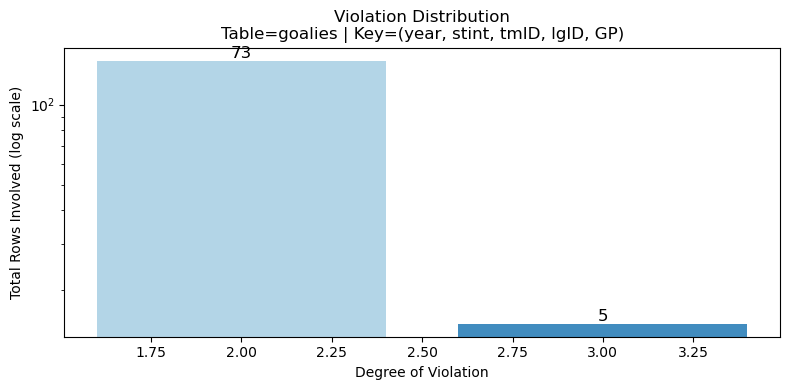

[SAVED] counter_example_result/goalies__year__stint__tmID__lgID__GP__pie.png


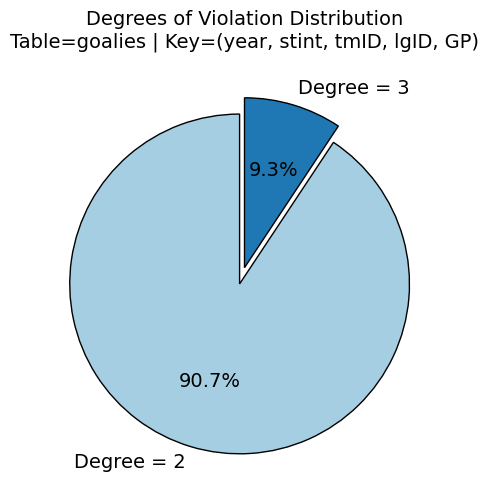


--- Table=goalies | Key=(year, stint, tmID, lgID, GP) | Degree=3 | Rows=5 ---
+---+------+-------+------+------+----+-------------+
| # | year | stint | tmID | lgID | GP | group_count |
+---+------+-------+------+------+----+-------------+
| 1 | 1943 |   1   | BOS  | NHL  | 1  |      3      |
| 2 | 1931 |   1   | NYA  | NHL  | 1  |      3      |
| 3 | 1968 |   1   | STL  | NHL  | 1  |      3      |
| 4 | 1931 |   1   | TOR  | NHL  | 1  |      3      |
| 5 | 1963 |   1   | DET  | NHL  | 1  |      3      |
+---+------+-------+------+------+----+-------------+

--- Table=goalies | Key=(year, stint, tmID, lgID, GP) | Degree=2 | Rows=73 ---
+---+------+-------+------+------+----+-------------+
| # | year | stint | tmID | lgID | GP | group_count |
+---+------+-------+------+------+----+-------------+
| 1 | 1984 |   1   | EDM  | NHL  | 1  |      2      |
| 2 | 1979 |   1   | BOS  | NHL  | 1  |      2      |
| 3 | 1972 |   1   | PHI  | NHL  | 23 |      2      |
| 4 | 1991 |   1   | BOS  | NHL

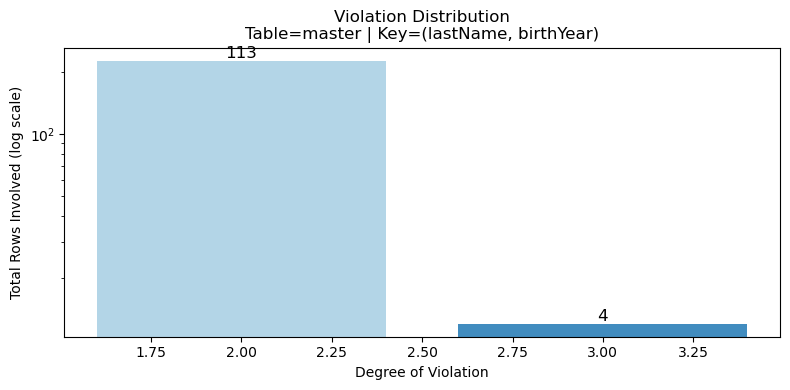

[SAVED] counter_example_result/master__lastName__birthYear__pie.png


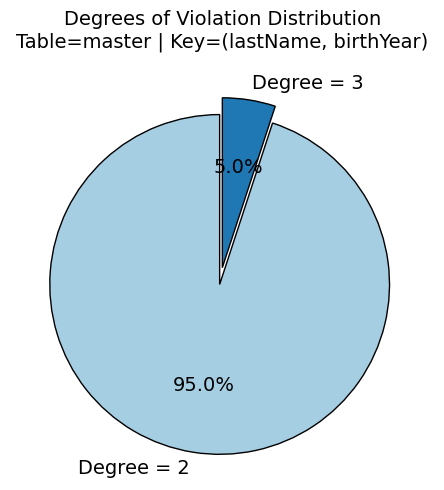


--- Table=master | Key=(lastName, birthYear) | Degree=3 | Rows=4 ---
+---+----------+-----------+-------------+
| # | lastName | birthYear | group_count |
+---+----------+-----------+-------------+
| 1 |  Smith   |    1963   |      3      |
| 2 |  Wilson  |    1962   |      3      |
| 3 |  Smith   |    1950   |      3      |
| 4 |  Smith   |    1977   |      3      |
+---+----------+-----------+-------------+

--- Table=master | Key=(lastName, birthYear) | Degree=2 | Rows=113 ---
+---+-------------+-----------+-------------+
| # |   lastName  | birthYear | group_count |
+---+-------------+-----------+-------------+
| 1 | Abrahamsson |    1947   |      2      |
| 2 |    Adams    |    1977   |      2      |
| 3 |    Adams    |    1904   |      2      |
| 4 |    Allen    |    1978   |      2      |
| 5 |   Allison   |    1959   |      2      |
+---+-------------+-----------+-------------+
[INFO] Showing only first 5 rows for Degree=2.

==================== Table: master; Near-key: ('last

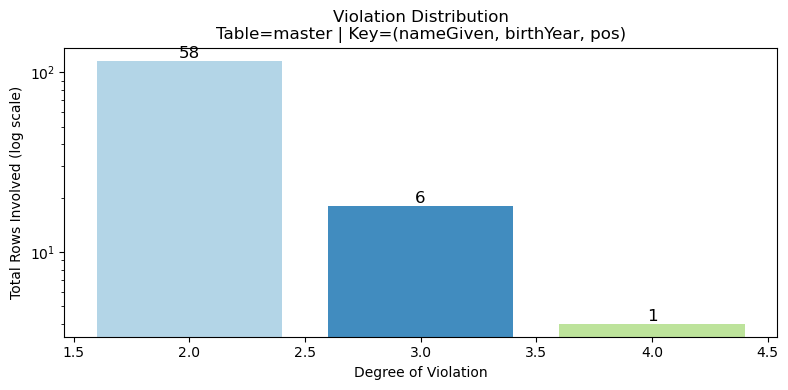

[SAVED] counter_example_result/master__nameGiven__birthYear__pos__pie.png


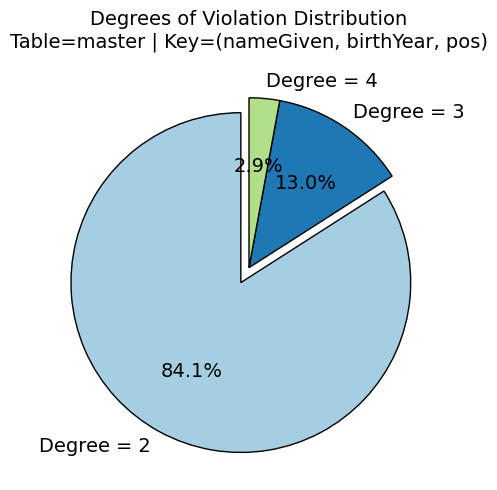


--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=4 | Rows=1 ---
+---+-----------+-----------+-----+-------------+
| # | nameGiven | birthYear | pos | group_count |
+---+-----------+-----------+-----+-------------+
| 1 |  Michael  |    1966   |  C  |      4      |
+---+-----------+-----------+-----+-------------+

--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=3 | Rows=6 ---
+---+-----------+-----------+-----+-------------+
| # | nameGiven | birthYear | pos | group_count |
+---+-----------+-----------+-----+-------------+
| 1 |   James   |    1967   |  D  |      3      |
| 2 |    Paul   |    1963   |  R  |      3      |
| 3 |    Dean   |    1968   |  D  |      3      |
| 4 |   Jason   |    1976   |  C  |      3      |
| 5 |   Scott   |    1969   |  L  |      3      |
+---+-----------+-----------+-----+-------------+
[INFO] Showing only first 5 rows for Degree=3.

--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=2 | Rows=58 ---
+---+-----------+-------

In [35]:
import os
import csv
import itertools
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from mysql.connector import Error


def degree_of_violation(cursor, table_name, columns):
    """
    Degree distribution
    duplicate_counts[degree] = total rows involved for this degree
    """
    if not columns:
        return {}

    cols_sql = ", ".join([f"`{col}`" for col in columns])
    not_null_cond = " AND ".join([f"`{col}` IS NOT NULL" for col in columns])

    query_duplicates = f"""
        SELECT {cols_sql}, COUNT(*) AS group_count
        FROM `{table_name}`
        WHERE {not_null_cond}
        GROUP BY {cols_sql}
        HAVING COUNT(*) > 1;
    """

    cursor.execute(query_duplicates)
    group_table = cursor.fetchall()

    duplicate_counts = {}
    for row in group_table:
        degree = int(row[-1])
        duplicate_counts[degree] = duplicate_counts.get(degree, 0) + degree

    return duplicate_counts


def fetch_duplicate_rows(cursor, table_name, columns):
    """Fetch duplicate detailed rows (show repeated field values) """

    cols_t = ", ".join([f"t.`{col}`" for col in columns])
    join_eq = " AND ".join([f"t.`{col}` = dup.`{col}`" for col in columns])

    query = f"""
        SELECT
            {cols_t},
            MAX(dup.group_count) AS group_count
        FROM `{table_name}` t
        JOIN (
            SELECT {", ".join([f"`{col}`" for col in columns])}, COUNT(*) AS group_count
            FROM `{table_name}`
            WHERE {" AND ".join([f"`{col}` IS NOT NULL" for col in columns])}
            GROUP BY {", ".join([f"`{col}`" for col in columns])}
            HAVING COUNT(*) > 1
        ) dup
          ON {join_eq}
        WHERE {" AND ".join([f"t.`{col}` IS NOT NULL" for col in columns])}
        GROUP BY {cols_t}
        ORDER BY group_count DESC;
    """

    cursor.execute(query)
    rows = cursor.fetchall()

    col_names = [desc[0] for desc in cursor.description]
    degree_idx = len(col_names) - 1

    grouped = {}
    for r in rows:
        degree = int(r[degree_idx])
        row_dict = {col_names[i]: r[i] for i in range(len(col_names))}
        grouped.setdefault(degree, []).append(row_dict)

    return grouped


def plot_violation_bar_chart(table_name, columns, degrees, values, colors, save_path=None):
    """Plot bar chart (only if multiple degrees)"""
    plt.figure(figsize=(8, 4))

    fig = plt.gcf()
    ax = plt.gca()

    # --- force white background (avoid Jupyter dark theme) ---
    fig.set_facecolor("white")
    ax.set_facecolor("white")

    # --- draw bars with the SAME colors list as pie chart ---
    ax.bar(degrees, values, color=colors, alpha=0.85)

    ax.set_yscale("log")

    # --- all text in black ---
    for x, y in zip(degrees, values):
        group_count = int(round(y / x))   # ✅ groups = total_rows / degree
        ax.text(x, y, str(group_count), fontsize=12, ha="center", va="bottom", color="black")


    ax.set_xlabel("Degree of Violation", color="black")
    ax.set_ylabel("Total Rows Involved (log scale)", color="black")
    ax.set_title(f"Violation Distribution\nTable={table_name} | Key=({', '.join(columns)})", color="black")

    ax.tick_params(axis="both", colors="black")

    for spine in ax.spines.values():
        spine.set_color("black")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"[SAVED] {save_path}")

    plt.show()
    plt.close()


def plot_violation_pie_chart(table_name, columns, degrees, ratios, colors, save_path=None):
    """Plot pie chart (always if duplicates exist)"""
    labels = [f"Degree = {degree}" for degree in degrees]
    explode = [0.1 if i == 0 else 0 for i in range(len(labels))]

    plt.figure(figsize=(5, 5))

    fig = plt.gcf()
    ax = plt.gca()

    # --- force white background ---
    fig.set_facecolor("white")
    ax.set_facecolor("white")

    # --- IMPORTANT: colors passed in, same order as degrees ---
    wedges, texts, autotexts = ax.pie(
        ratios,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=explode,
        wedgeprops={"edgecolor": "black"},
        textprops={"fontsize": 14, "color": "black"},
    )

    # ensure autopct text is black too
    for t in autotexts:
        t.set_color("black")

    ax.set_title(
        f"Degrees of Violation Distribution\nTable={table_name} | Key=({', '.join(columns)})",
        fontsize=14,
        color="black",
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"[SAVED] {save_path}")

    plt.show()
    plt.close()


def print_duplicate_details(table_name, columns, grouped_rows, max_rows_per_degree=20):
    """Print duplicate details grouped by degree"""
    if not grouped_rows:
        print("[INFO] No duplicate rows to display.")
        return

    display_cols = list(columns) + ["group_count"]

    for degree in sorted(grouped_rows.keys(), reverse=True):
        rows = grouped_rows[degree]
        print(f"\n--- Table={table_name} | Key=({', '.join(columns)}) | Degree={degree} | Rows={len(rows)} ---")

        pt = PrettyTable()
        pt.field_names = ["#"] + display_cols

        limit = len(rows) if max_rows_per_degree is None else min(len(rows), max_rows_per_degree)

        for i in range(limit):
            r = rows[i]
            pt.add_row([i + 1] + [r.get(col) for col in display_cols])

        print(pt)

        if max_rows_per_degree is not None and len(rows) > max_rows_per_degree:
            print(f"[INFO] Showing only first {max_rows_per_degree} rows for Degree={degree}.")


def main_degree(table_name, columns, max_rows_per_degree=20, output_folder="counter_example_result"):
    """Main wrapper: plot + show duplicate details + save plots"""

    connection = None
    cursor = None

    try:
        # make sure output folder exists
        os.makedirs(output_folder, exist_ok=True)

        connection = get_mysql_connection()
        cursor = connection.cursor()

        duplicate_counts = degree_of_violation(cursor, table_name, columns)

        if not duplicate_counts:
            print(f"[INFO] No duplicates found: Table={table_name}, Key=({', '.join(columns)})")
            return

        degrees = sorted(duplicate_counts.keys())
        values = [duplicate_counts[d] for d in degrees]

        total = sum(values)
        if total == 0:
            print(f"[INFO] Duplicate total is 0: Table={table_name}, Key=({', '.join(columns)})")
            return

        ratios = [v / total * 100 for v in values]

        # if only one degree -> skip all plots, show instances only
        if len(degrees) == 1:
            only_degree = degrees[0]
            print(
                f"[INFO] Only one degree found (Degree={only_degree}). "
                f"Skip bar/pie plots and show duplicate instances only."
            )
            grouped_rows = fetch_duplicate_rows(cursor, table_name, columns)
            print_duplicate_details(table_name, columns, grouped_rows, max_rows_per_degree=max_rows_per_degree)
            return

        # colors
        palette = list(plt.cm.Paired.colors)
        colors = [palette[i % len(palette)] for i in range(len(degrees))]

        # safe key name for filename
        key_str = "__".join(columns)
        key_str = "".join(ch if (ch.isalnum() or ch in ("_", "-", ".")) else "_" for ch in key_str)

        bar_save_path = os.path.join(output_folder, f"{table_name}__{key_str}__bar.png")
        pie_save_path = os.path.join(output_folder, f"{table_name}__{key_str}__pie.png")

        # plots (save + show)
        plot_violation_bar_chart(table_name, columns, degrees, values, colors, save_path=bar_save_path)
        plot_violation_pie_chart(table_name, columns, degrees, ratios, colors, save_path=pie_save_path)

        # duplicate details
        grouped_rows = fetch_duplicate_rows(cursor, table_name, columns)
        print_duplicate_details(table_name, columns, grouped_rows, max_rows_per_degree=max_rows_per_degree)

    except Error as e:
        print("[ERROR]", e)

    finally:
        if cursor is not None:
            cursor.close()
        if connection is not None and connection.is_connected():
            connection.close()


# =========================
# Run
# =========================
path = os.path.join("near_key_all.csv")

near_keys = []
with open(path, mode="r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        table_name = row["table_name"]
        combo = tuple(x.strip() for x in row["key"].split(",") if x.strip())
        ur = float(row["UR(max)"])
        cr = float(row["CR"])
        near_keys.append((table_name, combo, ur, cr))

print(f"[OK] loaded {len(near_keys)} near-keys from: {path}")

for table_name, combo, ur, cr in near_keys:
    if ur != 1.0:
        print(f"\n==================== Table: {table_name}; Near-key: {combo} ====================\n")
        main_degree(table_name, list(combo), max_rows_per_degree=5, output_folder="counter_example_result")


# --- Extension to Certain Keys ---
Using the **Master** table and the key **{firstName, lastName, birthYear, birthCity} (CFLY)** as an example, we illustrate the extension from **possible keys (URmax)** to **certain keys (URmin)** by showing how uniqueness, completeness, and runtime change when columns are removed.



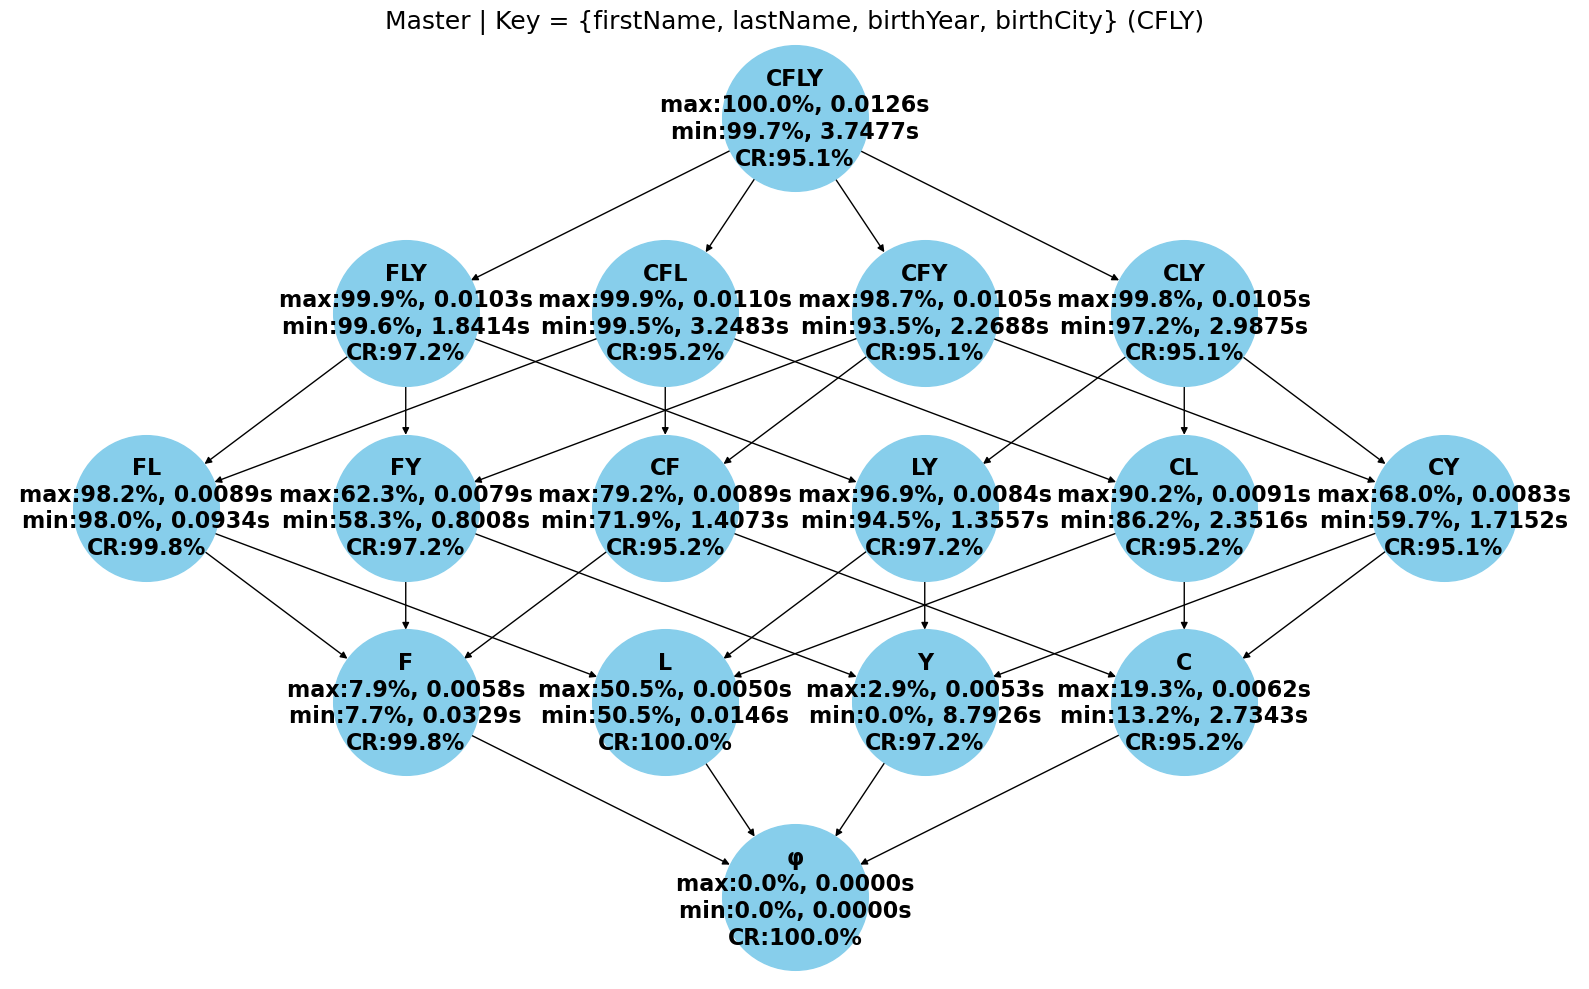

In [36]:
def normal_lattice(key_tuple):
    """Generate normal lattice levels from full set -> singletons -> φ"""
    sub_column = []
    for r in range(1, len(key_tuple) + 1):
        sub_column.append(list(itertools.combinations(key_tuple, r)))
    sub_column = sub_column[::-1]
    sub_column.append([("φ",)])
    return sub_column


sub_column = normal_lattice(tuple(full_key_cols))

def draw_vertical_lattice_with_certain(
    data,
    node_spacing=2.0,
    node_size=10000,
    font_size=20,
    pur_ratios=None,
    cur_ratios=None,
    cr_ratios=None,
    pur_times=None,
    cur_times=None,
    abbr_map=None,
    title=None,
):
    """
    Draw full lattice (connect all subset edges).
    Each node shows:
      - abbreviation (e.g. FLYC)
      - URmax (possible) in % + time
      - URmin (certain) in % + time
      - CR in %
    """
    G = nx.DiGraph()

    # Build nodes + positions
    unique_nodes = {}
    for level_idx, level in enumerate(data):
        for node_idx, node in enumerate(level):
            unique_nodes.setdefault(node, {})
            unique_nodes[node]["pos"] = ((node_idx - len(level) / 2) * node_spacing, -level_idx)

    # Add nodes with labels
    for node, attrs in unique_nodes.items():
        name = abbreviate_key(node, abbr_map) if abbr_map else ", ".join(node)

        pur = pur_ratios.get(node, 0.0) if pur_ratios else 0.0
        cur = cur_ratios.get(node, 0.0) if cur_ratios else 0.0
        cr  = cr_ratios.get(node, 0.0)  if cr_ratios  else 0.0

        t_pur = pur_times.get(node, None) if pur_times else None
        t_cur = cur_times.get(node, None) if cur_times else None

        pur_time_str = f", {t_pur:.4f}s" if t_pur is not None else ""
        cur_time_str = f", {t_cur:.4f}s" if t_cur is not None else ""

        label = (
            f"{name}\n"
            f"max:{pur*100:.1f}%{pur_time_str}\n"
            f"min:{cur*100:.1f}%{cur_time_str}\n"
            f"CR:{cr*100:.1f}%"
        )

        G.add_node(node, pos=attrs["pos"], label=label)

    # Add edges: subset relation between adjacent levels
    for level_idx in range(len(data) - 1):
        for parent in data[level_idx]:
            for child in data[level_idx + 1]:
                if is_subset(parent, child):
                    G.add_edge(parent, child)

    # Draw (force white background + black text)
    plt.figure(figsize=(16, 10))
    fig = plt.gcf()
    ax = plt.gca()
    fig.set_facecolor("white")
    ax.set_facecolor("white")

    pos = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=node_size,
        node_color="skyblue",
        font_size=font_size,
        font_weight="bold",
        arrows=True,
        edge_color="black",
        font_color="black",
    )

    if title:
        plt.title(title, fontsize=font_size + 2, color="black")

    plt.tight_layout()
    plt.show()


table_name = "Master"
full_key_cols = ["firstName", "lastName", "birthYear", "birthCity"]

abbr_map = {
    "firstName": "F",
    "lastName": "L",
    "birthYear": "Y",
    "birthCity": "C",
}

conn = None
cursor = None

try:
    conn = get_mysql_connection()
    cursor = conn.cursor()

    sub_column = normal_lattice(tuple(full_key_cols))

    pur_dic = {}
    cur_dic = {}
    cr_dic = {}

    pur_time_dic = {}
    cur_time_dic = {}

    for level in sub_column:
        for node in level:
            if node == ("φ",):
                pur_dic[node] = 0.0
                cur_dic[node] = 0.0
                cr_dic[node] = 1.0
                pur_time_dic[node] = 0.0
                cur_time_dic[node] = 0.0
                continue

            cols = list(node)

            # ---- recompute using your functions (UR + time) ----
            pur_val, pur_time = pmax_uniqueness_ratio_sql(cursor, table_name, cols)
            cur_val, cur_time = pmin_uniqueness_ratio(cursor, table_name, cols)
            cr_val = completeness_ratio(cursor, table_name, cols)

            pur_dic[node] = float(pur_val)
            cur_dic[node] = float(cur_val)
            cr_dic[node]  = float(cr_val)

            pur_time_dic[node] = float(pur_time)
            cur_time_dic[node] = float(cur_time)


    draw_vertical_lattice_with_certain(
        sub_column,
        node_spacing=2.5,
        node_size=11000,
        font_size=16,
        pur_ratios=pur_dic,
        cur_ratios=cur_dic,
        cr_ratios=cr_dic,
        pur_times=pur_time_dic,
        cur_times=cur_time_dic,
        abbr_map=abbr_map,
        title="Master | Key = {firstName, lastName, birthYear, birthCity} (CFLY)",
    )

finally:
    if cursor is not None:
        cursor.close()
    if conn is not None:
        conn.close()
